


# Feature Engineering on Titanic Dataset

#Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
from sklearn.model_selection import train_test_split


## Load dataset

In [9]:
df = pd.read_csv("/content/titanic_data_updated.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Starter columns

In [10]:
df.drop(['PassengerId','Name','Ticket'],axis = 1,inplace= True)

In [11]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [12]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [13]:
#train columns
X = df.drop(['Survived'],axis = 1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [14]:
#Target Column
y = df['Survived']
y

,Survived
0,no
1,yes
2,yes
3,yes
4,no
...,...
886,no
887,yes
888,no
889,yes


# Train_Test_Split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [16]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [17]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


In [18]:
y_train

,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [19]:
y_test

,Survived
709,yes
439,no
840,no
720,yes
39,yes
...,...
433,no
773,no
25,yes
84,yes


#Missing value with Pandas

In [20]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,140
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,2


In [21]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,37
SibSp,0
Parch,0
Fare,0
Cabin,134
Embarked,0


In [22]:
#mean impute
age_mean = X_train['Age'].mean()

X_train['age_mean_imputer']=X_train['Age'].fillna(age_mean)
X_test['age_median_imputer']=X_test["Age"].fillna(age_mean)

In [23]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer
331,first,male,45.5,0,0,28.5000,C124,S,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000


In [24]:
#median imputer
age_median = X_train['Age'].median()

X_train["age_median_imputer"]=X_train['Age'].fillna(age_median)
X_test['age_median_imputer']=X_test['Age'].fillna(age_median)

<Axes: xlabel='age_mean_imputer', ylabel='Density'>

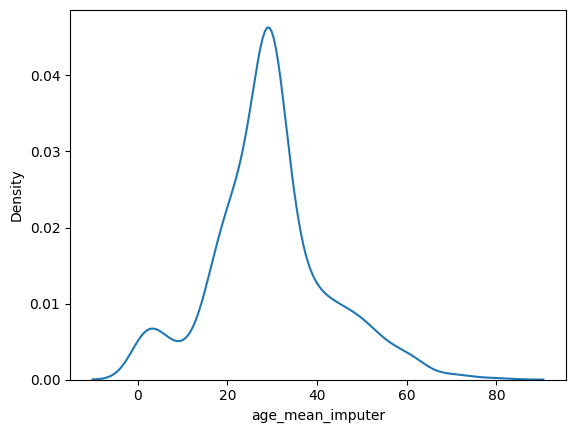

In [25]:
sns.kdeplot(data =X_train,x ='age_mean_imputer')

<Axes: xlabel='age_median_imputer', ylabel='Density'>

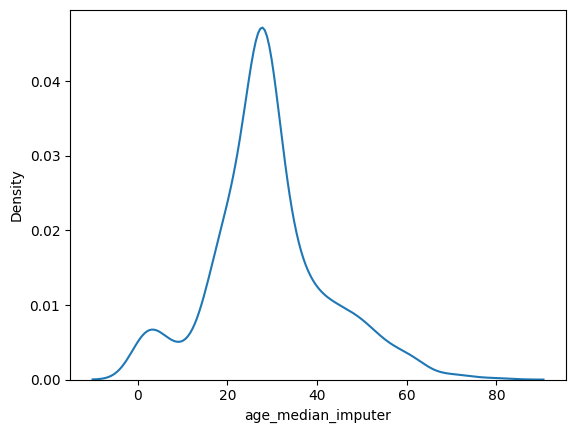

In [26]:
sns.kdeplot(data = X_train,x ='age_median_imputer')